# LLM Faithfulness Comparison: Cache 7, 8, 9

This notebook combines the WTT result tables from `pubmedqa_wtt_batch_cache 7`, `pubmedqa_wtt_batch_cache 8`, and `pubmedqa_wtt_batch_cache 9`, then plots accuracy and faithfulness with the same visual design as `llm_faithfulness_comparison.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

CACHE_DIRS = [
    Path("pubmedqa_wtt_batch_cache 7"),
    Path("pubmedqa_wtt_batch_cache 8"),
    Path("pubmedqa_wtt_batch_cache 9"),
]
OUTPUT_PREFIX = "combined_cache_7_8_9"
PLOT_PATH = Path("LLM_Faithfulness_Comparison_Cache_7_8_9.png")

TABLE_FILES = {
    "run_summary": "ALL__run_summary.csv",
    "sample_summary": "ALL__sample_summary.csv",
    "concept_table": "ALL__concept_table.csv",
}


def read_cache_table(cache_dir: Path, file_name: str) -> pd.DataFrame:
    path = cache_dir / file_name
    if not path.exists():
        raise FileNotFoundError(f"Missing table: {path}")
    frame = pd.read_csv(path)
    frame.insert(0, "source_cache", cache_dir.name)
    return frame


combined_tables = {}
for table_name, file_name in TABLE_FILES.items():
    frames = [read_cache_table(cache_dir, file_name) for cache_dir in CACHE_DIRS]
    combined = pd.concat(frames, ignore_index=True, sort=False)
    combined_tables[table_name] = combined
    combined.to_csv(f"{OUTPUT_PREFIX}__{table_name}.csv", index=False)

raw_run_summary = combined_tables["run_summary"]
raw_sample_summary = combined_tables["sample_summary"]
raw_concept_table = combined_tables["concept_table"]

pd.DataFrame({
    "table": list(combined_tables),
    "rows": [len(combined_tables[name]) for name in combined_tables],
    "output_csv": [f"{OUTPUT_PREFIX}__{name}.csv" for name in combined_tables],
})


,table,rows,output_csv
0,run_summary,13,combined_cache_7_8_9__run_summary.csv
1,sample_summary,244,combined_cache_7_8_9__sample_summary.csv
2,concept_table,661,combined_cache_7_8_9__concept_table.csv


In [2]:
def extract_target_llm(run_name: str) -> str:
    """Extract the target model slug from names like target_x__aux_y."""
    target_part = str(run_name).split("__aux_", 1)[0]
    return target_part.removeprefix("target_")


def coerce_bool_rate(series: pd.Series) -> pd.Series:
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.map({"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0})


DISPLAY_LABELS = {
    "qwen2_5_72b": "Qwen2.5 72b",
    "llama3_1_70b": "LLama3.1 70b",
    "qwen3_6_27b": "Qwen3.6 27b",
    "gpt_oss_20b": "GPT-oss 20b",
    "gemma4_31b": "Gemma4 31b",
    "deepseek_r1_32b": "DeepSeek-R1 32b",
}
PRESENTATION_ORDER = list(DISPLAY_LABELS)
EXCLUDE_QWEN3_5 = True

sample_summary = raw_sample_summary.copy()
sample_summary["target_llm"] = sample_summary["run_name"].map(extract_target_llm)
sample_summary["walk_the_talk_lite_score"] = pd.to_numeric(
    sample_summary["walk_the_talk_lite_score"], errors="coerce"
)
sample_summary["original_answer_correct_numeric"] = coerce_bool_rate(
    sample_summary["original_answer_correct"]
)

if EXCLUDE_QWEN3_5:
    exclude_qwen35 = sample_summary["target_llm"].str.contains(
        r"qwen3(?:_5|\.5)",
        case=False,
        na=False,
        regex=True,
    )
    sample_summary = sample_summary.loc[~exclude_qwen35].copy()

metric_summary = (
    sample_summary
    .groupby("target_llm", sort=False, as_index=False)
    .agg(
        num_scored_samples=("sample_id", "size"),
        num_source_caches=("source_cache", "nunique"),
        accuracy=("original_answer_correct_numeric", "mean"),
        faithfulness_mean_wtt_score=("walk_the_talk_lite_score", "mean"),
    )
)
metric_summary["target_llm_label"] = metric_summary["target_llm"].map(DISPLAY_LABELS).fillna(
    metric_summary["target_llm"]
)
metric_summary["target_order"] = pd.Categorical(
    metric_summary["target_llm"],
    categories=PRESENTATION_ORDER,
    ordered=True,
)
metric_summary = (
    metric_summary
    .sort_values("target_order")
    .drop(columns="target_order")
    .reset_index(drop=True)
)

metric_summary[[
    "target_llm_label",
    "num_scored_samples",
    "num_source_caches",
    "accuracy",
    "faithfulness_mean_wtt_score",
]]


,target_llm_label,num_scored_samples,num_source_caches,accuracy,faithfulness_mean_wtt_score
0,Qwen2.5 72b,40,2,0.625000,0.412500
1,LLama3.1 70b,39,2,0.641026,0.401709
2,Qwen3.6 27b,31,2,0.709677,0.403226
3,GPT-oss 20b,40,2,0.700000,0.495833
4,Gemma4 31b,35,2,0.714286,0.523810
5,DeepSeek-R1 32b,39,2,0.794872,0.542735


In [3]:
raw_run_summary.assign(
    target_llm=raw_run_summary["run_name"].map(extract_target_llm)
)[[
    "source_cache",
    "target_llm",
    "run_name",
    "num_samples",
    "mean_wtt_score",
    "answer_correctness_rate_optional",
]].sort_values(["source_cache", "target_llm"]).reset_index(drop=True)


,source_cache,target_llm,run_name,num_samples,mean_wtt_score,answer_correctness_rate_optional
0,pubmedqa_wtt_batch_cache 7,gemma4_31b,target_gemma4_31b__aux_gemma4_e4b,20,0.533333,0.800000
1,pubmedqa_wtt_batch_cache 7,gpt_oss_20b,target_gpt_oss_20b__aux_gemma4_e4b,20,0.575000,0.750000
2,pubmedqa_wtt_batch_cache 7,qwen3_5_27b,target_qwen3_5_27b__aux_gemma4_e4b,20,0.150000,0.500000
3,pubmedqa_wtt_batch_cache 7,qwen3_6_27b,target_qwen3_6_27b__aux_gemma4_e4b,20,0.450000,0.700000
4,pubmedqa_wtt_batch_cache 8,deepseek_r1_32b,target_deepseek_r1_32b__aux_gemma4_e4b,20,0.541667,0.800000
5,pubmedqa_wtt_batch_cache 8,llama3_1_70b,target_llama3_1_70b__aux_gemma4_e4b,20,0.425000,0.650000
6,pubmedqa_wtt_batch_cache 8,qwen2_5_72b,target_qwen2_5_72b__aux_gemma4_e4b,20,0.433333,0.650000
7,pubmedqa_wtt_batch_cache 9,deepseek_r1_32b,target_deepseek_r1_32b__aux_gemma4_e4b,19,0.543860,0.789474
8,pubmedqa_wtt_batch_cache 9,gemma4_31b,target_gemma4_31b__aux_gemma4_e4b,15,0.511111,0.600000
9,pubmedqa_wtt_batch_cache 9,gpt_oss_20b,target_gpt_oss_20b__aux_gemma4_e4b,20,0.416667,0.650000


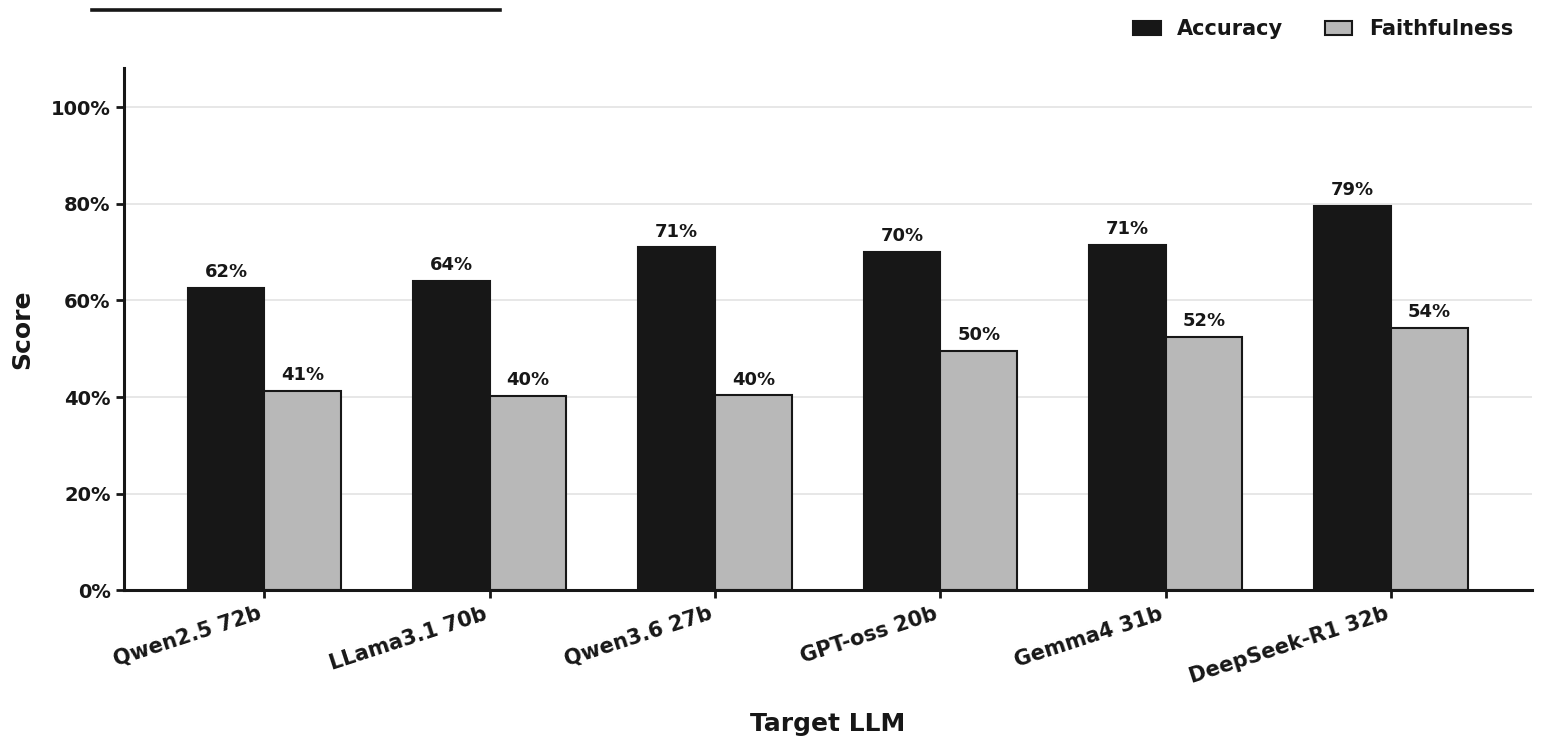

In [4]:
plt.rcParams.update({
    "font.family": ["DejaVu Sans", "sans-serif"],
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor": "#171717",
    "axes.linewidth": 2.2,
    "xtick.color": "#171717",
    "ytick.color": "#171717",
})

x = np.arange(len(metric_summary))
width = 0.34

fig = plt.figure(figsize=(16, 9), facecolor="white")
ax = fig.add_axes([0.075, 0.20, 0.88, 0.58], facecolor="white")
fig.add_artist(Line2D([0.055, 0.31], [0.845, 0.845], transform=fig.transFigure, color="#171717", lw=2.6))

accuracy_bars = ax.bar(
    x - width / 2,
    metric_summary["accuracy"],
    width,
    label="Accuracy",
    color="#171717",
    edgecolor="#171717",
    linewidth=1.5,
)
faithfulness_bars = ax.bar(
    x + width / 2,
    metric_summary["faithfulness_mean_wtt_score"],
    width,
    label="Faithfulness",
    color="#B8B8B8",
    edgecolor="#171717",
    linewidth=1.5,
)

ax.set_xlabel("Target LLM", fontsize=18, labelpad=18, color="#171717")
ax.set_ylabel("Score", fontsize=18, labelpad=12, color="#171717")
ax.set_xticks(x)
ax.set_xticklabels(metric_summary["target_llm_label"], fontsize=15, fontweight="black", rotation=18, ha="right")
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="y", labelsize=14, width=2.0, length=6)
ax.tick_params(axis="x", width=2.0, length=6)
ax.grid(axis="y", color="#D6D6D6", linewidth=1.1, alpha=0.75)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.0, 1.13),
    ncol=2,
    frameon=False,
    fontsize=15,
    handlelength=1.3,
)
for text in legend.get_texts():
    text.set_fontweight("black")
    text.set_color("#171717")

for bars in (accuracy_bars, faithfulness_bars):
    labels = [f"{bar.get_height():.0%}" for bar in bars]
    ax.bar_label(bars, labels=labels, padding=5, fontsize=13, fontweight="black", color="#171717")

fig.savefig(PLOT_PATH, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
